# kSZ Map Comparison: Simulated vs Reconstructed

Comparing kSZ maps at mean neutral fraction ~0.5

In [1]:
import sys
sys.path.insert(0, '../functions')

import numpy as np
import matplotlib.pyplot as plt
from generate_all_plots import (
    reconstruct_velocities, compute_ksz_maps,
    CENTRAL_CROP, LOS_CROP, PHYSICAL_NORM
)

In [2]:
# Redshifts and their approximate neutral fractions
# z ~ 7.5-7.6 corresponds to xHI ~ 0.5
# Let's find the exact one

redshifts_to_check = [6.617]

for z in redshifts_to_check:
    den, xhi, vx, vy, vz, vx_rec, vy_rec, vz_rec, vx_recx, vy_recx, vz_recx = reconstruct_velocities(z)
    mean_xhi = xhi.mean()
    print(f"z = {z:.3f}, mean xHI = {mean_xhi:.4f}")
    del den, xhi, vx, vy, vz, vx_rec, vy_rec, vz_rec, vx_recx, vy_recx, vz_recx

z = 6.617, mean xHI = 0.3548


In [3]:
# Load data for z ~ 7.57 (closest to xHI = 0.5)
z = 6.617

print(f"Loading data for z = {z}...")
den, xhi, vx, vy, vz, vx_rec, vy_rec, vz_rec, vx_recx, vy_recx, vz_recx = reconstruct_velocities(z)

# Apply central crop to avoid boundary effects
den = den[CENTRAL_CROP, CENTRAL_CROP, LOS_CROP]
xhi = xhi[CENTRAL_CROP, CENTRAL_CROP, LOS_CROP]
vz = vz[CENTRAL_CROP, CENTRAL_CROP, LOS_CROP]
vz_recx = vz_recx[CENTRAL_CROP, CENTRAL_CROP, LOS_CROP]

mean_xhi = xhi.mean()
print(f"Mean neutral fraction: {mean_xhi:.4f}")

Loading data for z = 6.617...
Mean neutral fraction: 0.3616


In [4]:
# Compute kSZ maps
print("Computing kSZ maps...")

# Simulated kSZ (from actual velocity field)
ksz_sim = compute_ksz_maps(vz, xhi, den, z=z, physical_norm=PHYSICAL_NORM)

# Reconstructed kSZ (from reconstructed velocity field, note the negative sign)
ksz_rec = compute_ksz_maps(-vz_recx, xhi, den, z=z, physical_norm=PHYSICAL_NORM)

print(f"Simulated kSZ: min={ksz_sim.min():.2f}, max={ksz_sim.max():.2f} µK")
print(f"Reconstructed kSZ: min={ksz_rec.min():.2f}, max={ksz_rec.max():.2f} µK")

Computing kSZ maps...
Simulated kSZ: min=-10.33, max=10.62 µK
Reconstructed kSZ: min=-25.61, max=15.83 µK


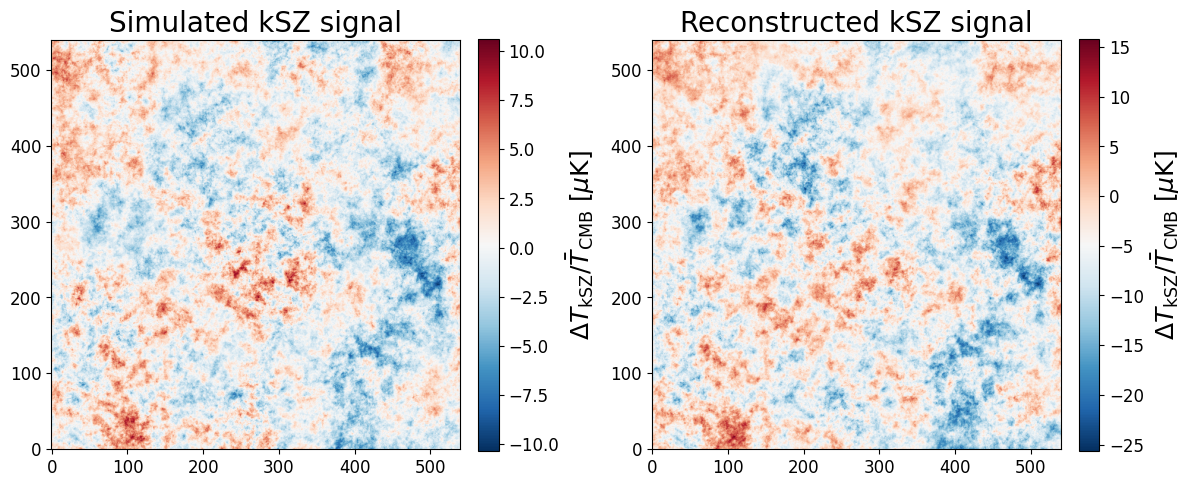

In [22]:
# Create clean comparison plot for paper
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Simulated kSZ map
ax = axes[0]
im0 = ax.imshow(ksz_sim, origin='lower', cmap='RdBu_r')
ax.set_title('Simulated kSZ signal', fontsize=20)
# ax.set_xlabel('x [pixels]', fontsize=14)
# ax.set_ylabel('y [pixels]', fontsize=14)
ax.tick_params(labelsize=12)
cbar0 = fig.colorbar(im0, ax=ax, fraction=0.046, pad=0.04)
cbar0.set_label('$\\Delta T_{\\mathrm{kSZ}} / \\bar{T}_{\\mathrm{CMB}}$ [$\\mu$K]', fontsize=18)
cbar0.ax.tick_params(labelsize=12)

# Reconstructed kSZ map
ax = axes[1]
im1 = ax.imshow(ksz_rec, origin='lower', cmap='RdBu_r')
ax.set_title('Reconstructed kSZ signal', fontsize=20)
# ax.set_xlabel('x [pixels]', fontsize=14)
# ax.set_ylabel('y [pixels]', fontsize=14)
ax.tick_params(labelsize=12)
cbar1 = fig.colorbar(im1, ax=ax, fraction=0.046, pad=0.04)
cbar1.set_label('$\\Delta T_{\\mathrm{kSZ}} / \\bar{T}_{\\mathrm{CMB}}$ [$\\mu$K]', fontsize=18)
cbar1.ax.tick_params(labelsize=12)

# Overall title
# fig.suptitle(f'kSZ Signal at $\\langle x_{{HI}} \\rangle$ = {mean_xhi:.2f} (z = {z:.2f})', 
#              fontsize=18, y=1.02)

plt.tight_layout()
plt.savefig('plots/ksz_map_comparison_xhi05.png', dpi=300, bbox_inches='tight')
plt.show()

In [6]:
# Compute correlation
from scipy.stats import pearsonr

r, p = pearsonr(ksz_sim.ravel(), ksz_rec.ravel())
print(f"Pearson correlation coefficient: r = {r:.4f}")
print(f"p-value: {p:.2e}")

Pearson correlation coefficient: r = 0.8578
p-value: 0.00e+00


Loading z = 6.617...
  Actual mean xHI at slice 100: 0.379
Loading z = 7.570...
  Actual mean xHI at slice 100: 0.717


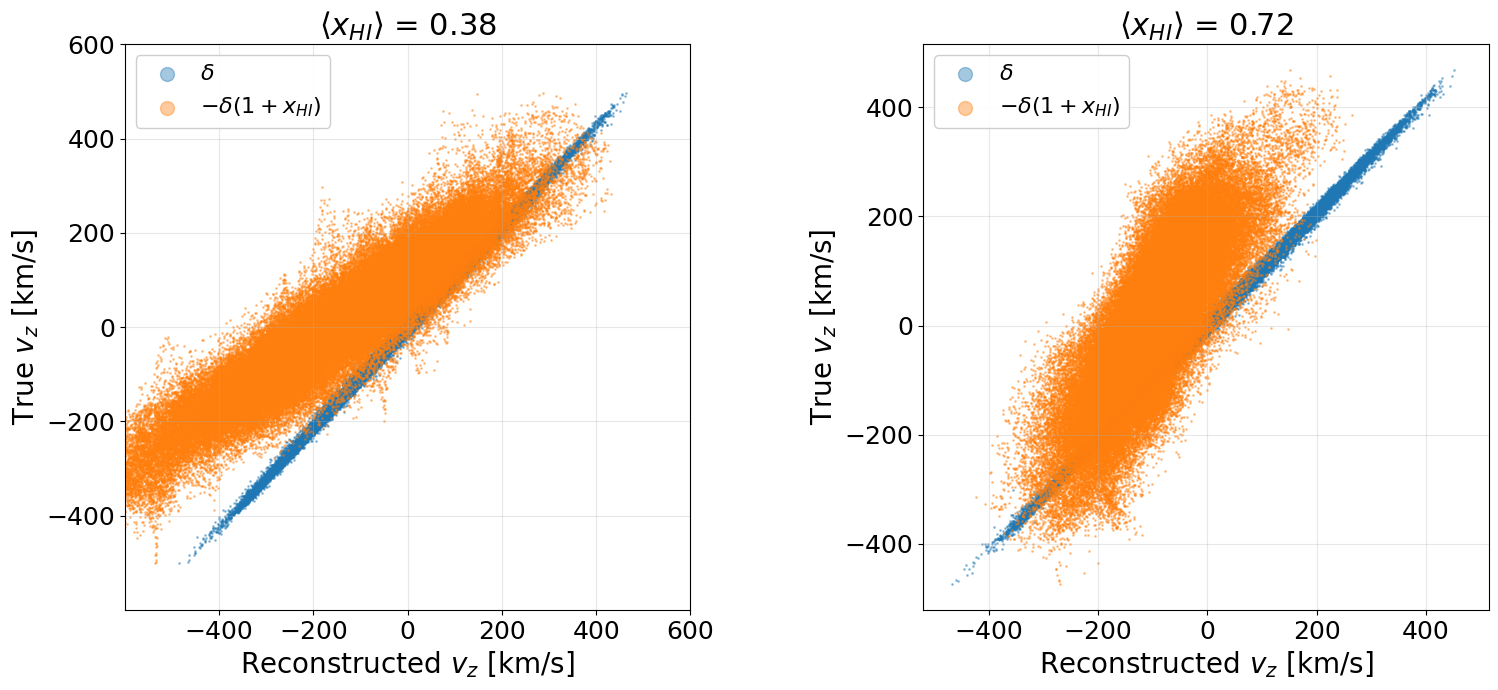

In [16]:
# Paper-quality scatter plot: velocity reconstruction comparison for two neutral fractions
# Blue: reconstruction from matter density field δ
# Orange: reconstruction from brightness temperature proxy δ(1 + x_HI)

def scatter_velocity_comparison_subplot(ax, vz_true, vz_rec_delta, vz_rec_Tb, 
                                         sample=150_000, seed=42, mean_xhi=None, axis_min_cap=None):
    """
    Create paper-quality scatter plot comparing velocity reconstructions on given axis.
    """
    from scipy.stats import pearsonr
    
    rng = np.random.default_rng(seed)
    
    # Flatten arrays
    t = vz_true.ravel()
    r_delta = vz_rec_delta.ravel()
    r_Tb = -vz_rec_Tb.ravel()  # Note negative sign for brightness temp reconstruction
    
    # Subsample for plotting
    n = t.size
    if sample is not None and sample < n:
        idx = rng.choice(n, size=sample, replace=False)
        t, r_delta, r_Tb = t[idx], r_delta[idx], r_Tb[idx]
    
    # Scatter plots with paper-quality labels
    ax.scatter(r_delta, t, s=1, alpha=0.4, color='C0', label='$\\delta$')
    ax.scatter(r_Tb, t, s=1, alpha=0.4, color='C1', label='$-\\delta(1 + x_{HI})$')
    
    # Determine axis limits to fit all data (especially orange blob)
    all_x = np.concatenate([r_delta, r_Tb])
    all_y = t
    x_min, x_max = np.nanmin(all_x), np.nanmax(all_x)
    y_min, y_max = np.nanmin(all_y), np.nanmax(all_y)
    
    # Add small margin
    x_margin = (x_max - x_min) * 0.05
    y_margin = (y_max - y_min) * 0.05
    
    x_min = x_min - x_margin
    x_max = x_max + x_margin
    y_min = y_min - y_margin
    y_max = y_max + y_margin
    
    # Use same range for both axes to keep square aspect
    data_min = min(x_min, y_min)
    data_max = max(x_max, y_max)
    
    # Apply axis_min cap if specified (caps both x and y for square plot)
    if axis_min_cap is not None:
        data_min = axis_min_cap
    
    ax.set_xlim(data_min, data_max)
    ax.set_ylim(data_min, data_max)
    
    # Remove -600 from tick labels if cap is applied
    if axis_min_cap is not None:
        # Get current ticks
        yticks = ax.get_yticks()
        xticks = ax.get_xticks()
        
        # Filter out -600
        yticks_filtered = [t for t in yticks if abs(t - axis_min_cap) > 1e-6]
        xticks_filtered = [t for t in xticks if abs(t - axis_min_cap) > 1e-6]
        
        ax.set_yticks(yticks_filtered)
        ax.set_xticks(xticks_filtered)
    
    # Formatting
    ax.set_xlabel('Reconstructed $v_z$ [km/s]', fontsize=20)
    ax.set_ylabel('True $v_z$ [km/s]', fontsize=20)
    
    if mean_xhi is not None:
        ax.set_title(f'$\\langle x_{{HI}} \\rangle$ = {mean_xhi:.2f}', fontsize=22)
    
    ax.legend(markerscale=10, fontsize=16, loc='upper left', framealpha=0.95, handletextpad=0.5)
    ax.tick_params(axis='both', which='major', labelsize=18)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, alpha=0.3)

# Redshifts corresponding to different neutral fractions
# Using higher redshift for left plot (lower xHI)
redshifts_xhi = [
    6.617,   # ~0.36 (was 6.483 with ~0.28)
    7.570,   # ~0.50
]

# Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

slice_idx = 100

for idx, z in enumerate(redshifts_xhi):
    print(f"Loading z = {z:.3f}...")
    den_full, xhi_full, vx, vy, vz_full, vx_rec, vy_rec, vz_rec_full, vx_recx, vy_recx, vz_recx_full = reconstruct_velocities(z)
    mean_xhi_slice = xhi_full[:, :, slice_idx].mean()
    print(f"  Actual mean xHI at slice {slice_idx}: {mean_xhi_slice:.3f}")
    
    # Apply axis min cap only to first (left) plot
    axis_min_cap = -600 if idx == 0 else None
    
    scatter_velocity_comparison_subplot(
        axes[idx],
        vz_true=vz_full[:, :, slice_idx],
        vz_rec_delta=vz_rec_full[:, :, slice_idx],
        vz_rec_Tb=vz_recx_full[:, :, slice_idx],
        sample=150_000,
        mean_xhi=mean_xhi_slice,
        axis_min_cap=axis_min_cap
    )
    
    del den_full, xhi_full, vx, vy, vz_full, vx_rec, vy_rec, vz_rec_full, vx_recx, vy_recx, vz_recx_full

plt.tight_layout()
plt.savefig('plots/scatter_vz_comparison_2panel.png', dpi=300, bbox_inches='tight')
plt.show()